In [2]:
import os
import ucimlrepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Iris Data

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
features = iris.data.features 
labels = iris.data.targets 

X = features.iloc[0:100,[0,2]].values
y = np.where(labels.iloc[0:100] == 'Iris-setosa', -1, 1).squeeze()

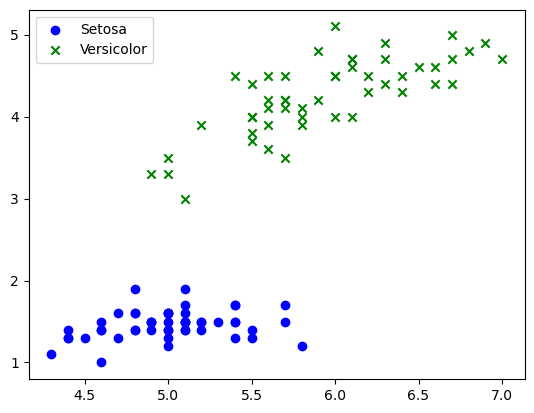

In [4]:
plt.scatter(X[:50, 0], X[:50,1],
            color='b', marker='o', label='Setosa')
plt.scatter(X[50:, 0], X[50:,1],
            color='g', marker='x', label='Versicolor')
plt.legend(loc='best')
plt.show()

## Perceptron Model

In [5]:
class adalineGD():
    def __init__(self, eta = 0.01, n_iter = 10, state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.state = state

    def fit(self, X, y):
        rgn = np.random.RandomState(self.state)
        self.w_ = rgn.normal(loc=0.0, scale=0.01,
                             size = 1 + X.shape[1])
        self.error_ = []
        
        for _ in range(self.n_iter):
            error = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                error += int(update != 0.0)
            self.error_.append(error)
        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def predict(self, X):
        return np.where(self.net_input(X) >= 0, 1, -1)

## Adaline Model

In [6]:
class adalineGD():
    def __init__(self, eta = 0.01, n_iter = 10, state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.state = state

    def fit(self, X, y):
        rgn = np.random.RandomState(self.state)
        self.w_ = rgn.normal(loc=0.0, scale=0.01,
                             size = 1 + X.shape[1])
        self.loss_ = []

        for _ in range(self.n_iter):
            net_input = self.net_input(X)
            outputs = self.activation(net_input)
            errors = y - outputs
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors ** 2).sum() / 2
            self.loss_.append(cost)

        return self
    
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def activation(self, X):
        return X
    
    def predict(self, X):
        return np.where(self.activation(X) >= 0, 1, -1)

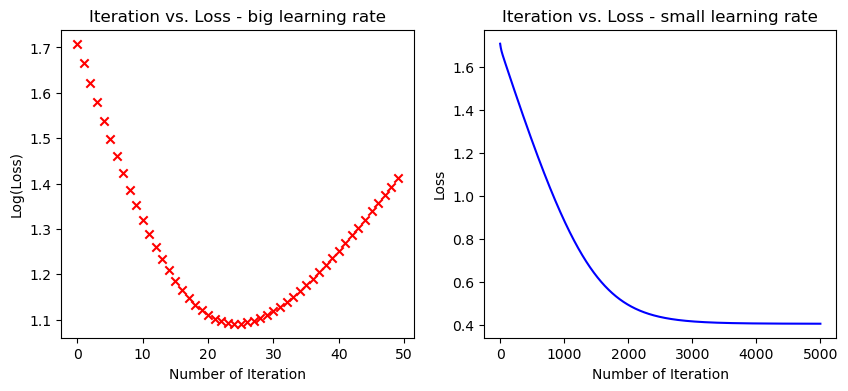

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
adal1 = adalineGD(eta=0.0005, n_iter=50).fit(X, y)
ax[0].scatter(np.arange(len(adal1.loss_)), 
              np.log10(adal1.loss_), marker='x',
              color='r')
ax[0].set_xlabel('Number of Iteration')
ax[0].set_ylabel('Log(Loss)')
ax[0].set_title('Iteration vs. Loss - big learning rate')

adal2 = adalineGD(eta=0.00001, n_iter=5000).fit(X, y)
ax[1].plot(np.arange(len(adal2.loss_)), 
              np.log10(adal2.loss_),
              color='b')
ax[1].set_xlabel('Number of Iteration')
ax[1].set_ylabel('Loss')
ax[1].set_title('Iteration vs. Loss - small learning rate')
plt.show()

## Feature scaling

In [8]:
X_std = np.copy(X)
X_std[:, 0] = (X_std[:,0] - X_std[:,0].mean()) / X_std[:,0].std()
X_std[:, 1] = (X_std[:,1] - X_std[:,1].mean()) / X_std[:,1].std()

After the normalization, the learning rate can be set as 0.01, which is much bigger



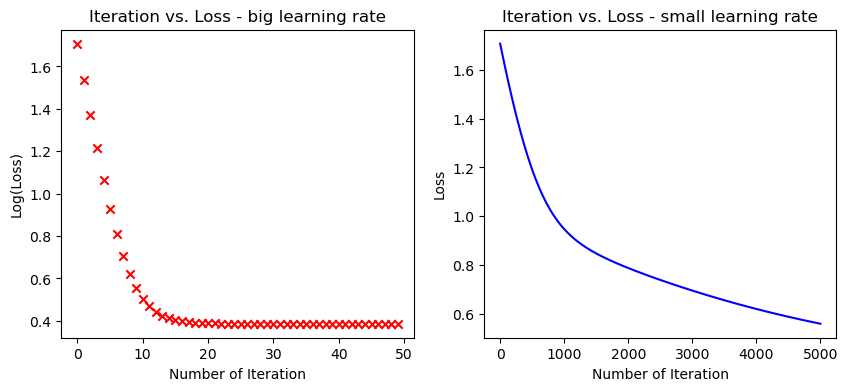

In [9]:
print('After the normalization, the learning rate can be set as 0.01, which is much bigger', end='\n\n')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
adal1 = adalineGD(eta=0.01, n_iter=50).fit(X_std, y)
ax[0].scatter(np.arange(len(adal1.loss_)), 
              np.log10(adal1.loss_), marker='x',
              color='r')
ax[0].set_xlabel('Number of Iteration')
ax[0].set_ylabel('Log(Loss)')
ax[0].set_title('Iteration vs. Loss - big learning rate')

adal2 = adalineGD(eta=0.00001, n_iter=5000).fit(X_std, y)
ax[1].plot(np.arange(len(adal2.loss_)), 
              np.log10(adal2.loss_),
              color='b')
ax[1].set_xlabel('Number of Iteration')
ax[1].set_ylabel('Loss')
ax[1].set_title('Iteration vs. Loss - small learning rate')
plt.show()